# Install Dependencies

In [1]:
!pip install torch torchvision opencv-python matplotlib tqdm

# Import Libraries

In [2]:
import os
import glob
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from tqdm import tqdm

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# Data Preprocessing

## Dataset Directory Configuration

In [4]:
import glob
import os

TRAIN_LOW_DIR = "/kaggle/input/datasets/soumikrakshit/lol-dataset/lol_dataset/our485/low"
TRAIN_HIGH_DIR = "/kaggle/input/datasets/soumikrakshit/lol-dataset/lol_dataset/our485/high"

TEST_LOW_DIR = "/kaggle/input/datasets/soumikrakshit/lol-dataset/lol_dataset/eval15/low"
TEST_HIGH_DIR = "/kaggle/input/datasets/soumikrakshit/lol-dataset/lol_dataset/eval15/high"

train_low = sorted(glob.glob(os.path.join(TRAIN_LOW_DIR, "*")))
train_high = sorted(glob.glob(os.path.join(TRAIN_HIGH_DIR, "*")))

test_low = sorted(glob.glob(os.path.join(TEST_LOW_DIR, "*")))
test_high = sorted(glob.glob(os.path.join(TEST_HIGH_DIR, "*")))

print("Train pairs:", len(train_low))
print("Test pairs:", len(test_low))

Train pairs: 485
Test pairs: 15


## Custom Dataset Class

In [5]:
class LOL_Dataset(Dataset):
    def __init__(self, low_paths, high_paths, transform=None):
        self.low_paths = low_paths
        self.high_paths = high_paths
        self.transform = transform

    def __len__(self):
        return len(self.low_paths)

    def __getitem__(self, idx):

        low = cv2.imread(self.low_paths[idx])
        high = cv2.imread(self.high_paths[idx])

        low = cv2.cvtColor(low, cv2.COLOR_BGR2RGB)
        high = cv2.cvtColor(high, cv2.COLOR_BGR2RGB)

        if self.transform:
            low = self.transform(low)
            high = self.transform(high)

        return low, high

## Image Transformations

In [6]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((256,256)),
    transforms.ToTensor()
])

## Data Splitting

In [7]:
train_dataset = LOL_Dataset(train_low, train_high, transform)
test_dataset = LOL_Dataset(test_low, test_high, transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

Training samples: 485
Testing samples: 15


# U-Net Model Implementation

In [8]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels,out_channels,3,padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels,out_channels,3,padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self,x):
        return self.conv(x)


class UNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.down1 = DoubleConv(3,64)
        self.down2 = DoubleConv(64,128)
        self.down3 = DoubleConv(128,256)
        self.down4 = DoubleConv(256,512)

        self.pool = nn.MaxPool2d(2)

        self.up1 = nn.ConvTranspose2d(512,256,2,stride=2)
        self.conv1 = DoubleConv(512,256)

        self.up2 = nn.ConvTranspose2d(256,128,2,stride=2)
        self.conv2 = DoubleConv(256,128)

        self.up3 = nn.ConvTranspose2d(128,64,2,stride=2)
        self.conv3 = DoubleConv(128,64)

        self.final = nn.Conv2d(64,3,1)

    def forward(self,x):

        c1 = self.down1(x)
        p1 = self.pool(c1)

        c2 = self.down2(p1)
        p2 = self.pool(c2)

        c3 = self.down3(p2)
        p3 = self.pool(c3)

        c4 = self.down4(p3)

        u1 = self.up1(c4)
        u1 = torch.cat([u1,c3],dim=1)
        c5 = self.conv1(u1)

        u2 = self.up2(c5)
        u2 = torch.cat([u2,c2],dim=1)
        c6 = self.conv2(u2)

        u3 = self.up3(c6)
        u3 = torch.cat([u3,c1],dim=1)
        c7 = self.conv3(u3)

        output = torch.sigmoid(self.final(c7))

        return output

In [9]:
model = UNet().to(device)

criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print("Model initialized")

Model initialized


## Training

In [10]:
EPOCHS = 20

for epoch in range(EPOCHS):

    model.train()
    train_loss = 0

    for low, high in tqdm(train_loader):

        low = low.to(device)
        high = high.to(device)

        optimizer.zero_grad()

        output = model(low)

        loss = criterion(output, high)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} Loss: {train_loss/len(train_loader):.4f}")

100%|██████████| 61/61 [00:29<00:00,  2.10it/s]


Epoch 1/20 Loss: 0.1760


100%|██████████| 61/61 [00:20<00:00,  2.99it/s]


Epoch 2/20 Loss: 0.1478


100%|██████████| 61/61 [00:20<00:00,  2.99it/s]


...

Epoch 18/20 Loss: 0.1177


100%|██████████| 61/61 [00:20<00:00,  3.01it/s]


Epoch 19/20 Loss: 0.1155


100%|██████████| 61/61 [00:19<00:00,  3.08it/s]

Epoch 20/20 Loss: 0.1158


## Evaluation

In [11]:
def evaluate_model(model, dataloader):

    model.eval()

    total_loss = 0

    with torch.no_grad():

        for low, high in dataloader:

            low = low.to(device)
            high = high.to(device)

            output = model(low)

            loss = criterion(output, high)

            total_loss += loss.item()

    print("Validation Loss:", total_loss/len(dataloader))

In [13]:
evaluate_model(model, test_loader)

Validation Loss: 0.11556051919857661


## Save the Model

In [17]:
torch.save(model.state_dict(), "unet_lol_enhancement.pth")

# Results

In [14]:
def show_results(model, dataset, num_images=3):

    model.eval()

    fig, axes = plt.subplots(num_images,3, figsize=(10,10))

    for i in range(num_images):

        low, high = dataset[i]

        with torch.no_grad():

            pred = model(low.unsqueeze(0).to(device)).cpu().squeeze()

        low = low.permute(1,2,0).numpy()
        high = high.permute(1,2,0).numpy()
        pred = pred.permute(1,2,0).numpy()

        axes[i,0].imshow(low)
        axes[i,0].set_title("Low Light")

        axes[i,1].imshow(pred)
        axes[i,1].set_title("Enhanced")

        axes[i,2].imshow(high)
        axes[i,2].set_title("Ground Truth")

        for j in range(3):
            axes[i,j].axis("off")

    plt.show()

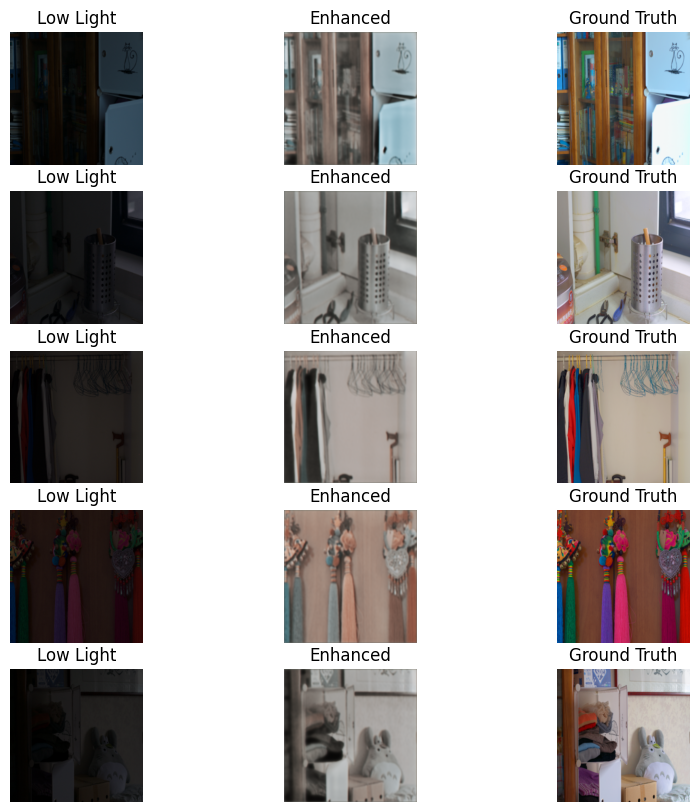

In [16]:
show_results(model, test_dataset, num_images=5)